## Least squares approximation

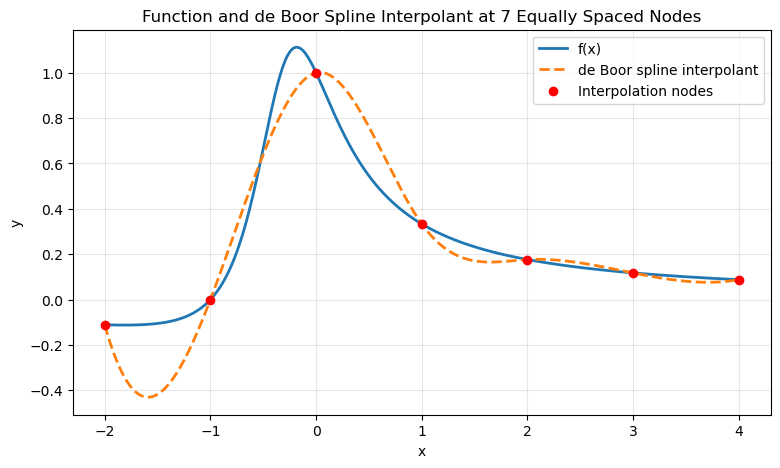

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splrep, splev

# Function definition
f = lambda x: (x + 1) / (3 * x**2 + 2 * x + 1)

# 7 equally spaced interpolation nodes on [-2, 4]
x_nodes = np.linspace(-2, 4, 7)
y_nodes = f(x_nodes)

# de Boor spline interpolant (B-spline representation, exact interpolation with s=0)
tck = splrep(x_nodes, y_nodes, s=0, k=3)

# Dense grid for smooth plotting
x_plot = np.linspace(-2, 4, 500)
y_true = f(x_plot)
y_spline = splev(x_plot, tck)

# Plot f, spline interpolant, and nodes on the same axes
plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_true, label='f(x)', color='tab:blue', linewidth=2)
plt.plot(x_plot, y_spline, '--', label='de Boor spline interpolant', color='tab:orange', linewidth=2)
plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='Interpolation nodes')

plt.title('Function and de Boor Spline Interpolant at 7 Equally Spaced Nodes')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

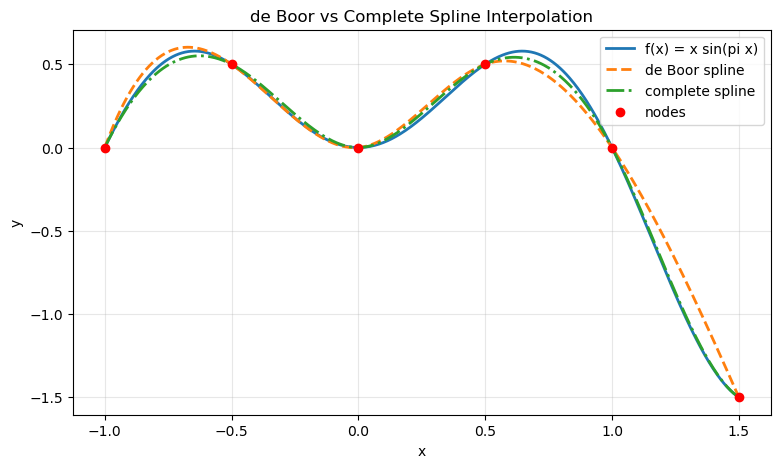

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splrep, splev, CubicSpline

# Data
f = lambda x: x * np.sin(np.pi * x)
fp = lambda x: np.sin(np.pi * x) + np.pi * x * np.cos(np.pi * x)  # derivative of f

x_nodes = np.array([-1, -1/2, 0, 1/2, 1, 3/2], dtype=float)
y_nodes = f(x_nodes)

# a) de Boor spline (B-spline interpolation form)
tck_deboor = splrep(x_nodes, y_nodes, s=0, k=3)

# a) Complete cubic spline (clamped: endpoint first derivatives specified)
complete_spline = CubicSpline(
    x_nodes,
    y_nodes,
    bc_type=((1, fp(x_nodes[0])), (1, fp(x_nodes[-1])))
)

# b) Plot on [-1, 3/2]
x_plot = np.linspace(-1, 1.5, 600)
y_true = f(x_plot)
y_deboor = splev(x_plot, tck_deboor)
y_complete = complete_spline(x_plot)

plt.figure(figsize=(9, 5))
plt.plot(x_plot, y_true, label='f(x) = x sin(pi x)', color='tab:blue', linewidth=2)
plt.plot(x_plot, y_deboor, '--', label='de Boor spline', color='tab:orange', linewidth=2)
plt.plot(x_plot, y_complete, '-.', label='complete spline', color='tab:green', linewidth=2)
plt.scatter(x_nodes, y_nodes, color='red', zorder=5, label='nodes')

plt.title('de Boor vs Complete Spline Interpolation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Best polynomial degree: 1
Polynomial coefficients (highest power first):
[0.63172542 4.70992579]
SSE error at nodes: 0.209750
Estimated value at x=4.0: 7.236827


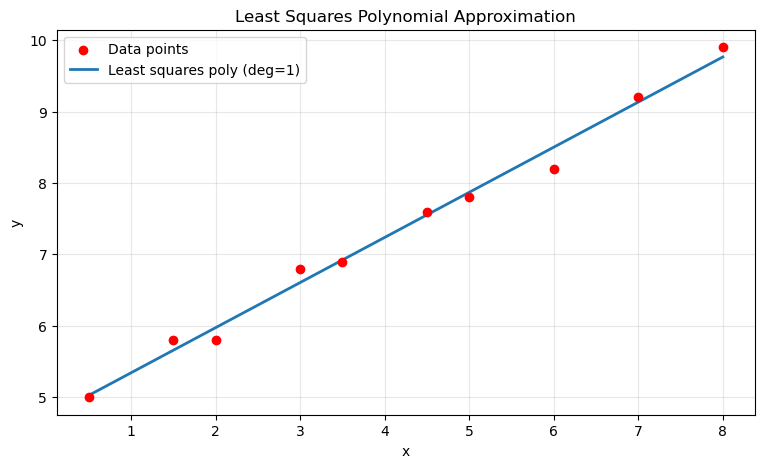

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Given data
x_raw = np.array([0.5, 1.5, 2, 3, 3.5, 4.5, 5, 6, 7, 8], dtype=float)
y_raw = np.array([5, 5.8, 5.8, 6.8, 6.9, 7.6, 7.8, 8.2, 9.2, 9.9], dtype=float)

# Use full provided paired data
x = x_raw
y = y_raw

# a) Least-squares polynomial fit with degree 1 (line)
max_degree = min(1, len(x) - 1)
best_degree, best_coeffs, best_sse = None, None, np.inf

for deg in range(1, max_degree + 1):
    coeffs = np.polyfit(x, y, deg)
    p = np.poly1d(coeffs)
    sse = np.sum((y - p(x)) ** 2)
    if sse < best_sse:
        best_sse = sse
        best_degree = deg
        best_coeffs = coeffs

p_best = np.poly1d(best_coeffs)

print(f"Best polynomial degree: {best_degree}")
print("Polynomial coefficients (highest power first):")
print(best_coeffs)

# b) Approximation error: sum of squared residuals at data points
error_sse = np.sum((y - p_best(x)) ** 2)
print(f"SSE error at nodes: {error_sse:.6f}")

# c) Estimate value at x = 4
x_est = 4.0
y_est = p_best(x_est)
print(f"Estimated value at x={x_est}: {y_est:.6f}")

# d) Plot data and approximation polynomial
x_plot = np.linspace(x.min(), x.max(), 500)
y_plot = p_best(x_plot)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, color='red', label='Data points', zorder=5)
plt.plot(x_plot, y_plot, color='tab:blue', linewidth=2, label=f'Least squares poly (deg={best_degree})')
plt.title('Least Squares Polynomial Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()